In [52]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [53]:
# Load data (each line: label <TAB> message)
df = pd.read_csv('sms_spam_dataset.csv', sep='\t', header=None, names=['label', 'message'])
print(df.shape)  # Expect around (5574, 2)

(5572, 2)


In [54]:
# Quick peek
print(df.head())
print(df['label'].value_counts(normalize=True))

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


In [55]:
# Encode labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [56]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

In [57]:
# Feature extraction with TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [58]:
#Logistic Regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
# PR curve metrics
y_scores = clf.predict_proba(X_test_tfidf)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)


In [60]:
# Precision-Recall metrics
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)


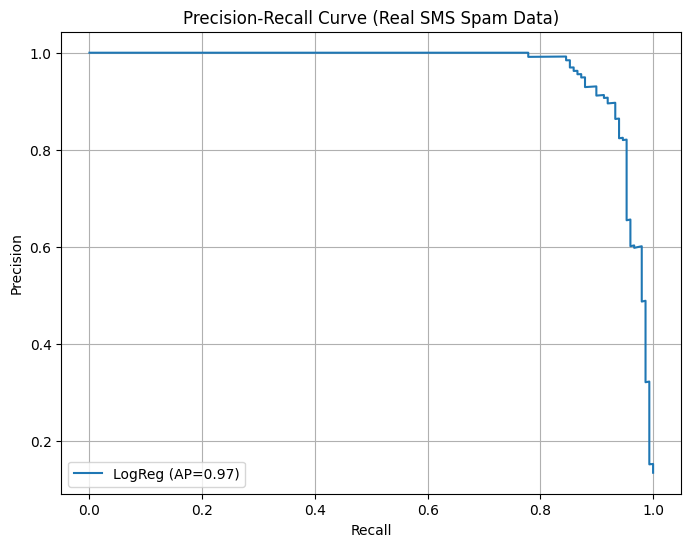

In [61]:
# Plot curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'LogReg (AP={avg_precision:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Real SMS Spam Data)")
plt.legend()
plt.grid(True)
plt.show() 

In [62]:
# Extra eval: Confusion matrix & classification report
y_pred = clf.predict(X_test_tfidf)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Confusion Matrix:
[[966   0]
 [ 36 113]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

